# Prediction de la variation journaliere des prix a terme de l'electricite
### Master 2 IEF - Data Science 2025/2026
---

## 1. Problematique et approche

Ce projet predit la **variation journaliere des prix a terme d'electricite** (TARGET) pour la France et l'Allemagne. La metrique imposee est le **coefficient de correlation de Spearman**.

Les prix sont determines par le **merit order**. Les facteurs cles : mix de production, meteo, prix des matieres premieres (gaz, charbon, carbone), echanges transfrontaliers.

**Approche** : deux modeles separes (FR et DE), testes sur valeurs brutes vs rangs normalises.

## 2. Import librairies

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import subprocess
import os
import shap
warnings.filterwarnings('ignore')

from scipy.stats import spearmanr
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet, LassoCV
from sklearn.model_selection import cross_val_score, KFold, GridSearchCV, RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.cluster import KMeans
from sklearn.metrics import make_scorer, silhouette_score

SEED = 42
np.random.seed(SEED)

ROOT_DIR      = os.path.abspath("")
DATA_DIR      = os.path.join(ROOT_DIR, "data/")
PROCESSED_DIR = os.path.join(ROOT_DIR, "data/processed/")

GAS_EFFICIENCY       = 0.5
GAS_EMISSION_FACTOR  = 0.4
COAL_EFFICIENCY      = 0.5
COAL_EMISSION_FACTOR = 1

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 3. Importation et preparation des donnees

### 3.1 Metrique d'evaluation

Le **Spearman** mesure la qualite du **classement** des predictions.
On testera le fit sur les **valeurs brutes** vs les **rangs normalises** pour voir lequel aligne mieux l'objectif d'entrainement avec la metrique.

In [2]:
def spearman_scorer(y_true, y_pred):
    corr, _ = spearmanr(y_true, y_pred)
    return corr

spearman_metric = make_scorer(spearman_scorer)
cv = KFold(n_splits=5, shuffle=True, random_state=SEED)

### 3.2 Import des donnees

In [3]:
for f in ['x_train_pr.csv', 'x_test_pr.csv', 'y_train_pr.csv']:
    path = PROCESSED_DIR + f
    if os.path.exists(path):
        os.remove(path)

print('Running data_prep.py...')
subprocess.run(['python', 'data_prep.py'], check=True, cwd=ROOT_DIR)

x_train_pr = pd.read_csv(PROCESSED_DIR + 'x_train_pr.csv', index_col='ID')
x_test_pr  = pd.read_csv(PROCESSED_DIR + 'x_test_pr.csv',  index_col='ID')
y_train_pr = pd.read_csv(PROCESSED_DIR + 'y_train_pr.csv', index_col='ID')

print(f'x_train_pr : {x_train_pr.shape}')
print(f'x_test_pr  : {x_test_pr.shape}')
print(f'y_train_pr : {y_train_pr.shape} | colonnes : {y_train_pr.columns.tolist()}')

Running data_prep.py...


X_train : (1494, 35)
y_train : (1494, 2)
X_test  : (654, 35)

── Construction des features économiques ──
Features éco construites : MARGINAL_GAS, MARGINAL_COAL
GAS_RET, COAL_RET, CARBON_RET supprimées

── Imputation (médiane globale, params du train) ──
Valeurs manquantes train : 0
Valeurs manquantes test  : 0

── Standardisation globale (params du train) ──
  31 features standardisées (train : 1494 obs, test : 654 obs)

── Construction de y_train_pr ──
y_train_pr : (1494, 2) | colonnes : ['values', 'rank']
x_train_pr : (1494, 31)
x_test_pr  : (654, 31)

✅ Fichiers exportés dans /Users/marcjehannin/Desktop/MASTER/M2/COURS/S2/ML/explaining-electricity-prices/data/processed/
   x_train_pr.csv | x_test_pr.csv | y_train_pr.csv
x_train_pr : (1494, 31)
x_test_pr  : (654, 31)
y_train_pr : (1494, 2) | colonnes : ['values', 'rank']


### 3.3 Split par pays et creation des datasets

In [4]:
# IDs par pays depuis les fichiers bruts (x_train_pr n'a plus COUNTRY)
x_train_raw = pd.read_csv(DATA_DIR + 'X_train.csv').set_index('ID')
x_test_raw  = pd.read_csv(DATA_DIR + 'X_test.csv').set_index('ID')

ids_fr_train = x_train_raw[x_train_raw['COUNTRY'] == 'FR'].index
ids_de_train = x_train_raw[x_train_raw['COUNTRY'] == 'DE'].index
IDS_FR       = x_test_raw[x_test_raw['COUNTRY']  == 'FR'].index
IDS_DE       = x_test_raw[x_test_raw['COUNTRY']  == 'DE'].index

print(f"Train FR : {len(ids_fr_train)} | Train DE : {len(ids_de_train)}")
print(f"Test  FR : {len(IDS_FR)}       | Test  DE : {len(IDS_DE)}")

x_train_fr = x_train_pr.loc[ids_fr_train].sort_index()
x_train_de = x_train_pr.loc[ids_de_train].sort_index()
x_test_fr  = x_test_pr.loc[IDS_FR]
x_test_de  = x_test_pr.loc[IDS_DE]

y_fr_values = y_train_pr.loc[ids_fr_train, 'values'].sort_index()
y_de_values = y_train_pr.loc[ids_de_train, 'values'].sort_index()
y_fr_rank   = y_train_pr.loc[ids_fr_train, 'rank'].sort_index()
y_de_rank   = y_train_pr.loc[ids_de_train, 'rank'].sort_index()

X_full        = x_train_pr
X_test_full   = x_test_pr
y_full_values = y_train_pr['values']
y_full_rank   = y_train_pr['rank']

assert (x_train_fr.index == y_fr_values.index).all(), "Index FR non aligne"
assert (x_train_de.index == y_de_values.index).all(), "Index DE non aligne"
print("Index alignes OK")
os.makedirs('submissions', exist_ok=True)

# Dictionnaire centralisé des resultats
# results[modele][scope_target] = {score_cv, score_train, model, params, ...}
results = {}

Train FR : 851 | Train DE : 643
Test  FR : 365       | Test  DE : 289
Index alignes OK


### 3.4 Fonctions utilitaires

In [5]:
def cv_score(model, X, y):
    '''Spearman CV moyen sur 5 folds.'''
    return cross_val_score(model, X, y, cv=cv, scoring=spearman_metric).mean()

def fit_eval(model, X_tr, y_tr, label=''):
    '''
    Fit le modele, calcule Spearman CV et train.
    Retourne (score_cv, score_train, gap).
    '''
    s_cv    = cv_score(model, X_tr, y_tr)
    model.fit(X_tr, y_tr)
    s_train = spearmanr(y_tr, model.predict(X_tr)).correlation
    gap     = s_train - s_cv
    diag    = 'OK' if gap < 0.05 else ('WARN' if gap < 0.15 else 'OVERFIT')
    print(f"  {label:50s} | CV={s_cv:.4f} | Train={s_train:.4f} | Gap={gap:.4f} [{diag}]")
    return s_cv, s_train, gap

def find_best_alpha_elbow(model_class, alphas, X, y, **kwargs):
    '''
    Meilleur alpha par methode du coude sur Spearman CV.
    Aucun Scaler ajoute — donnees deja standardisees.
    '''
    scores = np.array([cv_score(model_class(alpha=a, **kwargs), X, y) for a in alphas])
    n      = len(scores)
    p1, p2 = np.array([0, scores[0]]), np.array([n-1, scores[-1]])
    lv     = (p2 - p1) / np.linalg.norm(p2 - p1)
    dists  = [abs(np.cross(lv, np.array([i, s]) - p1)) for i, s in enumerate(scores)]
    return alphas[np.argmax(dists)]

def elbow_threshold(values):
    '''Coude geometrique dans une courbe.'''
    n      = len(values)
    coords = np.column_stack([np.arange(n), values])
    lv     = coords[-1] - coords[0]
    lv_n   = lv / np.linalg.norm(lv)
    dists  = np.abs(np.cross(coords - coords[0], lv_n))
    return np.argmax(dists)

def print_comparison_table(results_dict, title="COMPARAISON SPEARMAN CV"):
    '''Tableau de comparaison de tous les modeles enregistres.'''
    print(f"\n{'='*80}")
    print(f" {title}")
    print(f"{'='*80}")
    print(f"  {'Modele':50s} | {'CV':7s} | {'Train':7s} | {'Gap':6s} | Diag")
    print("  " + "-"*76)
    for label, d in results_dict.items():
        s_cv, s_tr = d['score_cv'], d['score_train']
        gap  = s_tr - s_cv
        diag = 'OK' if gap < 0.05 else ('WARN' if gap < 0.15 else 'OVERFIT')
        print(f"  {label:50s} | {s_cv:.4f} | {s_tr:.4f} | {gap:.4f} | {diag}")

## 4. OLS (modele de reference)

L'OLS est notre point de depart. On le teste sur :
- **Full dataset** vs **par pays** : justifie la modelisation separee
- **Values** vs **Rank** : justifie si fitter sur les rangs ameliore le Spearman

### 4.1 OLS Full dataset

In [6]:
results['OLS'] = {}
print("="*80)
print(" OLS - FULL DATASET")
print("="*80)

for target_type, y in [('values', y_full_values), ('rank', y_full_rank)]:
    model         = LinearRegression()
    s_cv, s_tr, _ = fit_eval(model, X_full, y, f"OLS full - {target_type}")
    results['OLS'][f'full_{target_type}'] = {'score_cv': s_cv, 'score_train': s_tr,
                                              'model': model, 'params': {},
                                              'x_test': X_test_full}

 OLS - FULL DATASET
  OLS full - values                                  | CV=0.0033 | Train=0.0831 | Gap=0.0799 [WARN]
  OLS full - rank                                    | CV=-0.0124 | Train=0.1194 | Gap=0.1319 [WARN]


### 4.2 OLS Par pays

In [7]:
print("="*80)
print(" OLS - PAR PAYS")
print("="*80)

for country, X_tr, X_te, y_vals, y_rnk in [
    ('FR', x_train_fr, x_test_fr, y_fr_values, y_fr_rank),
    ('DE', x_train_de, x_test_de, y_de_values, y_de_rank),
]:
    for target_type, y in [('values', y_vals), ('rank', y_rnk)]:
        model         = LinearRegression()
        s_cv, s_tr, _ = fit_eval(model, X_tr, y, f"OLS {country} - {target_type}")
        results['OLS'][f'{country}_{target_type}'] = {'score_cv': s_cv, 'score_train': s_tr,
                                                       'model': model, 'params': {},
                                                       'x_test': X_te}

 OLS - PAR PAYS
  OLS FR - values                                    | CV=0.1405 | Train=0.2215 | Gap=0.0810 [WARN]
  OLS FR - rank                                      | CV=0.1910 | Train=0.2833 | Gap=0.0923 [WARN]
  OLS DE - values                                    | CV=0.3227 | Train=0.4401 | Gap=0.1174 [WARN]
  OLS DE - rank                                      | CV=0.3478 | Train=0.4513 | Gap=0.1035 [WARN]


### 4.3 Analyse OLS


 OLS - COMPARAISON COMPLETE
  Modele                                             | CV      | Train   | Gap    | Diag
  ----------------------------------------------------------------------------
  full_values                                        | 0.0033 | 0.0831 | 0.0799 | WARN
  full_rank                                          | -0.0124 | 0.1194 | 0.1319 | WARN
  FR_values                                          | 0.1405 | 0.2215 | 0.0810 | WARN
  FR_rank                                            | 0.1910 | 0.2833 | 0.0923 | WARN
  DE_values                                          | 0.3227 | 0.4401 | 0.1174 | WARN
  DE_rank                                            | 0.3478 | 0.4513 | 0.1035 | WARN

Lecture :
  full vs par pays -> pertinence modelisation separee FR/DE
  values vs rank   -> alignement objectif entrainement / metrique Spearman


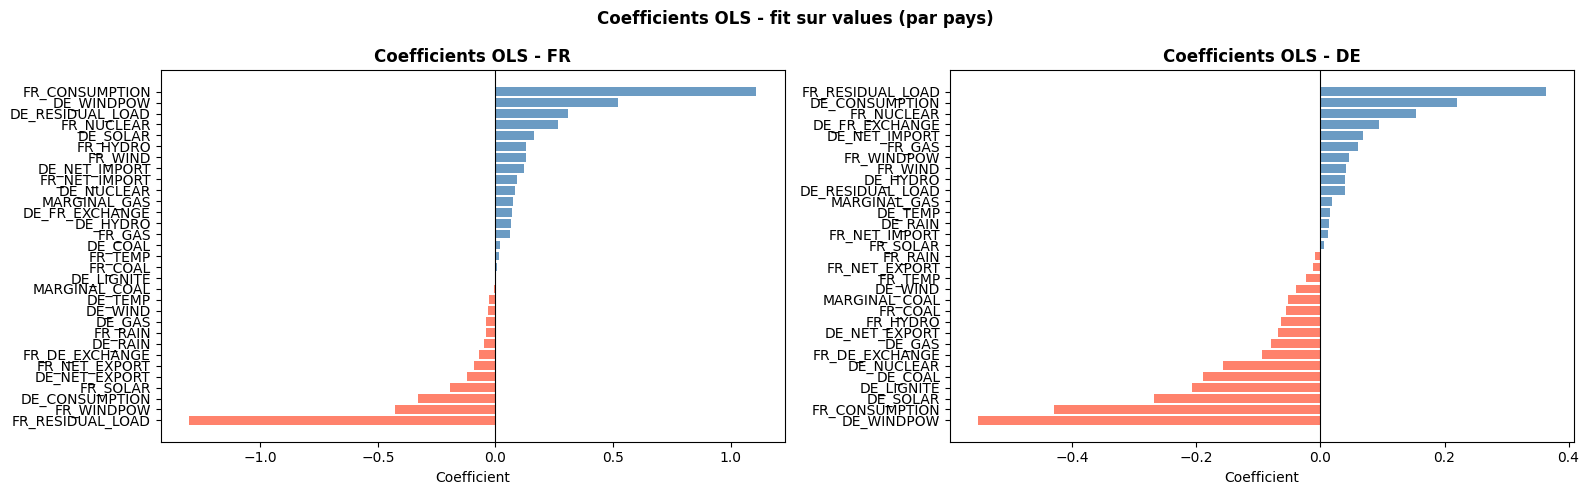

submission submissions/submission_ols_values.csv genere (654 lignes)
submission submissions/submission_ols_rank.csv genere (654 lignes)


In [8]:
print_comparison_table(results['OLS'], "OLS - COMPARAISON COMPLETE")

print("\nLecture :")
print("  full vs par pays -> pertinence modelisation separee FR/DE")
print("  values vs rank   -> alignement objectif entrainement / metrique Spearman")

# Coefficients OLS par pays
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("Coefficients OLS - fit sur values (par pays)", fontweight='bold')
for ax, country, X_tr, y_tr in [
    (axes[0], 'FR', x_train_fr, y_fr_values),
    (axes[1], 'DE', x_train_de, y_de_values),
]:
    m = LinearRegression().fit(X_tr, y_tr)
    coefs = pd.Series(m.coef_, index=X_tr.columns).sort_values()
    colors = ['tomato' if c < 0 else 'steelblue' for c in coefs]
    ax.barh(coefs.index, coefs.values, color=colors, alpha=0.8)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title(f'Coefficients OLS - {country}', fontweight='bold')
    ax.set_xlabel('Coefficient')
plt.tight_layout(); plt.show()

# Soumissions OLS
for target_type in ['values', 'rank']:
    sub = pd.concat([
        pd.DataFrame({'ID': IDS_FR,
                      'TARGET': results['OLS'][f'FR_{target_type}']['model'].predict(
                                results['OLS'][f'FR_{target_type}']['x_test'])}),
        pd.DataFrame({'ID': IDS_DE,
                      'TARGET': results['OLS'][f'DE_{target_type}']['model'].predict(
                                results['OLS'][f'DE_{target_type}']['x_test'])}),
    ]).sort_values('ID').reset_index(drop=True)
    fname = f'submissions/submission_ols_{target_type}.csv'
    sub.to_csv(fname, index=False)
    print(f"submission {fname} genere ({len(sub)} lignes)")

## 5. Ridge

Regularisation L2 : penalise les grands coefficients pour reduire la variance.
Alpha optimal par **methode du coude** sur la courbe Spearman CV vs alpha (grille log-scale).

### 5.1 Ridge Full dataset

In [9]:
results['Ridge'] = {}
alphas = np.logspace(-3, 3, 50)

print("="*80)
print(" RIDGE - FULL DATASET")
print("="*80)

for target_type, y in [('values', y_full_values), ('rank', y_full_rank)]:
    best_alpha = find_best_alpha_elbow(Ridge, alphas, X_full, y)
    model      = Ridge(alpha=best_alpha)
    s_cv, s_tr, _ = fit_eval(model, X_full, y,
                              f"Ridge full - {target_type} | alpha={best_alpha:.3f}")
    results['Ridge'][f'full_{target_type}'] = {'score_cv': s_cv, 'score_train': s_tr,
                                                'model': model, 'params': {'alpha': best_alpha},
                                                'x_test': X_test_full}

 RIDGE - FULL DATASET
  Ridge full - values | alpha=104.811                | CV=0.0089 | Train=0.0823 | Gap=0.0734 [WARN]
  Ridge full - rank | alpha=138.950                  | CV=-0.0076 | Train=0.1170 | Gap=0.1246 [WARN]


### 5.2 Ridge Par pays

In [10]:
print("="*80)
print(" RIDGE - PAR PAYS")
print("="*80)

for country, X_tr, X_te, y_vals, y_rnk in [
    ('FR', x_train_fr, x_test_fr, y_fr_values, y_fr_rank),
    ('DE', x_train_de, x_test_de, y_de_values, y_de_rank),
]:
    for target_type, y in [('values', y_vals), ('rank', y_rnk)]:
        best_alpha = find_best_alpha_elbow(Ridge, alphas, X_tr, y)
        model      = Ridge(alpha=best_alpha)
        s_cv, s_tr, _ = fit_eval(model, X_tr, y,
                                  f"Ridge {country} - {target_type} | alpha={best_alpha:.3f}")
        results['Ridge'][f'{country}_{target_type}'] = {
            'score_cv': s_cv, 'score_train': s_tr,
            'model': model, 'params': {'alpha': best_alpha},
            'x_test': X_te}

 RIDGE - PAR PAYS
  Ridge FR - values | alpha=184.207                  | CV=0.1694 | Train=0.2320 | Gap=0.0626 [WARN]
  Ridge FR - rank | alpha=323.746                    | CV=0.2144 | Train=0.2744 | Gap=0.0600 [WARN]
  Ridge DE - values | alpha=138.950                  | CV=0.3366 | Train=0.4209 | Gap=0.0843 [WARN]
  Ridge DE - rank | alpha=104.811                    | CV=0.3566 | Train=0.4288 | Gap=0.0722 [WARN]


### 5.3 Analyse Ridge


 RIDGE - COMPARAISON COMPLETE
  Modele                                             | CV      | Train   | Gap    | Diag
  ----------------------------------------------------------------------------
  full_values                                        | 0.0089 | 0.0823 | 0.0734 | WARN
  full_rank                                          | -0.0076 | 0.1170 | 0.1246 | WARN
  FR_values                                          | 0.1694 | 0.2320 | 0.0626 | WARN
  FR_rank                                            | 0.2144 | 0.2744 | 0.0600 | WARN
  DE_values                                          | 0.3366 | 0.4209 | 0.0843 | WARN
  DE_rank                                            | 0.3566 | 0.4288 | 0.0722 | WARN

Ridge vs OLS - Gain de la regularisation :
  full_values               | OLS=0.0033 | Ridge=0.0089 | Gain=+0.0056
  full_rank                 | OLS=-0.0124 | Ridge=-0.0076 | Gain=+0.0048
  FR_values                 | OLS=0.1405 | Ridge=0.1694 | Gain=+0.0288
  FR_rank          

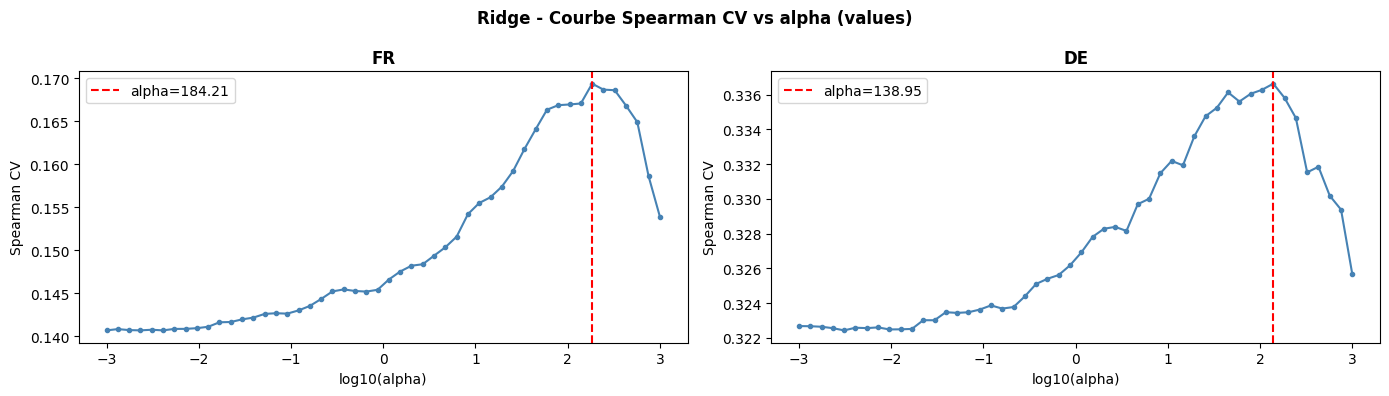

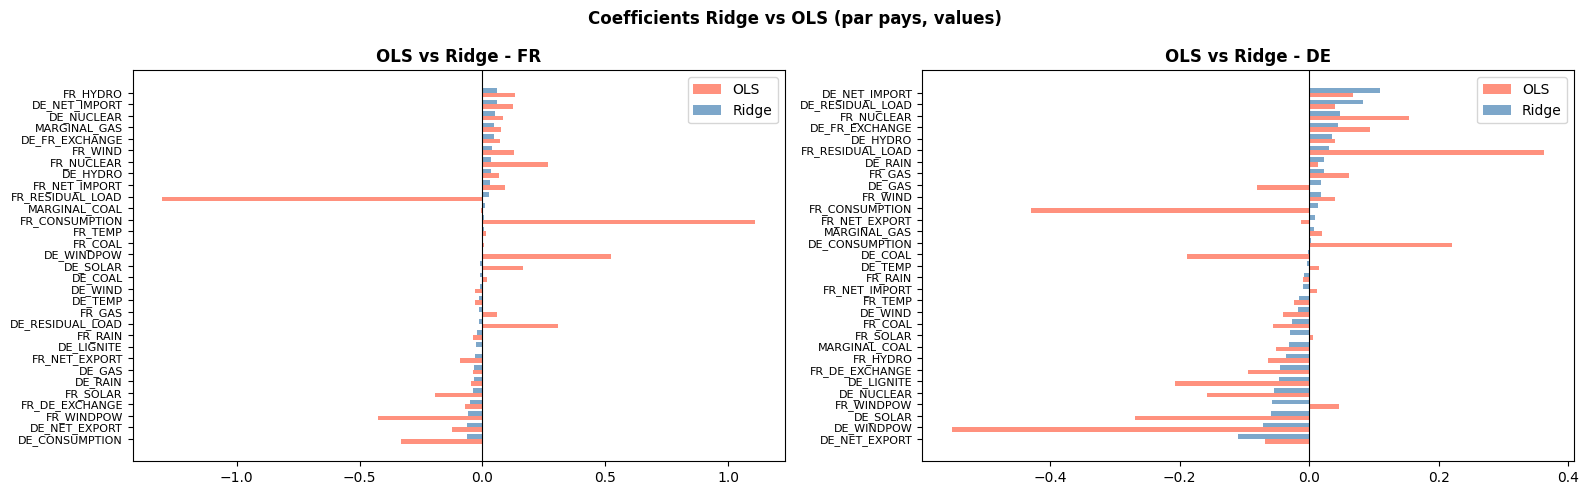

submission submissions/submission_ridge_values.csv genere (654 lignes)
submission submissions/submission_ridge_rank.csv genere (654 lignes)


In [11]:
print_comparison_table(results['Ridge'], "RIDGE - COMPARAISON COMPLETE")

print("\nRidge vs OLS - Gain de la regularisation :")
for key in results['OLS']:
    s_ols   = results['OLS'][key]['score_cv']
    s_ridge = results['Ridge'].get(key, {}).get('score_cv', None)
    if s_ridge is not None:
        gain = s_ridge - s_ols
        print(f"  {key:25s} | OLS={s_ols:.4f} | Ridge={s_ridge:.4f} | Gain={gain:+.4f}")

# Courbes alpha par pays
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle("Ridge - Courbe Spearman CV vs alpha (values)", fontweight='bold')
for ax, country, X_tr, y_tr in [
    (axes[0], 'FR', x_train_fr, y_fr_values),
    (axes[1], 'DE', x_train_de, y_de_values),
]:
    scores = np.array([cv_score(Ridge(alpha=a), X_tr, y_tr) for a in alphas])
    best_a = results['Ridge'][f'{country}_values']['params']['alpha']
    ax.plot(np.log10(alphas), scores, color='steelblue', marker='o', markersize=3)
    ax.axvline(np.log10(best_a), color='red', linestyle='--', label=f'alpha={best_a:.2f}')
    ax.set_title(f'{country}', fontweight='bold')
    ax.set_xlabel('log10(alpha)'); ax.set_ylabel('Spearman CV'); ax.legend()
plt.tight_layout(); plt.show()

# Coefficients Ridge vs OLS par pays
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("Coefficients Ridge vs OLS (par pays, values)", fontweight='bold')
for ax, country, X_tr, y_tr in [
    (axes[0], 'FR', x_train_fr, y_fr_values),
    (axes[1], 'DE', x_train_de, y_de_values),
]:
    ols_coefs   = pd.Series(LinearRegression().fit(X_tr, y_tr).coef_, index=X_tr.columns)
    ridge_coefs = pd.Series(results['Ridge'][f'{country}_values']['model'].coef_,
                             index=X_tr.columns)
    comp  = pd.DataFrame({'OLS': ols_coefs, 'Ridge': ridge_coefs}).sort_values('Ridge')
    x_pos = np.arange(len(comp))
    ax.barh(x_pos - 0.2, comp['OLS'],   0.4, label='OLS',   color='tomato',    alpha=0.7)
    ax.barh(x_pos + 0.2, comp['Ridge'], 0.4, label='Ridge', color='steelblue', alpha=0.7)
    ax.set_yticks(x_pos); ax.set_yticklabels(comp.index, fontsize=8)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title(f'OLS vs Ridge - {country}', fontweight='bold')
    ax.legend()
plt.tight_layout(); plt.show()

# Soumissions Ridge
for target_type in ['values', 'rank']:
    sub = pd.concat([
        pd.DataFrame({'ID': IDS_FR,
                      'TARGET': results['Ridge'][f'FR_{target_type}']['model'].predict(
                                results['Ridge'][f'FR_{target_type}']['x_test'])}),
        pd.DataFrame({'ID': IDS_DE,
                      'TARGET': results['Ridge'][f'DE_{target_type}']['model'].predict(
                                results['Ridge'][f'DE_{target_type}']['x_test'])}),
    ]).sort_values('ID').reset_index(drop=True)
    fname = f'submissions/submission_ridge_{target_type}.csv'
    sub.to_csv(fname, index=False)
    print(f"submission {fname} genere ({len(sub)} lignes)")

## 6. Clustering (modele non supervise)

Le KMeans identifie des **regimes de marche** dans l'espace des features.
Le label cluster est utilise comme **feature supplementaire** pour le Ridge via **One-Hot Encoding**.

Pourquoi OHE ?
- Encoder le cluster comme entier suppose une relation ordinale sans sens economique.
- Avec OHE, chaque cluster devient une variable binaire independante.

Pourquoi pas Ridge par cluster ?
- En CV, le KMeans re-entraine a chaque fold produit des labels instables -> Spearman catastrophique.
- Les labels fixes sur tout le train + OHE donnent une CV stable.

### 6.1 Choix du nombre de clusters K

FR | K retenu = 6
DE | K retenu = 5


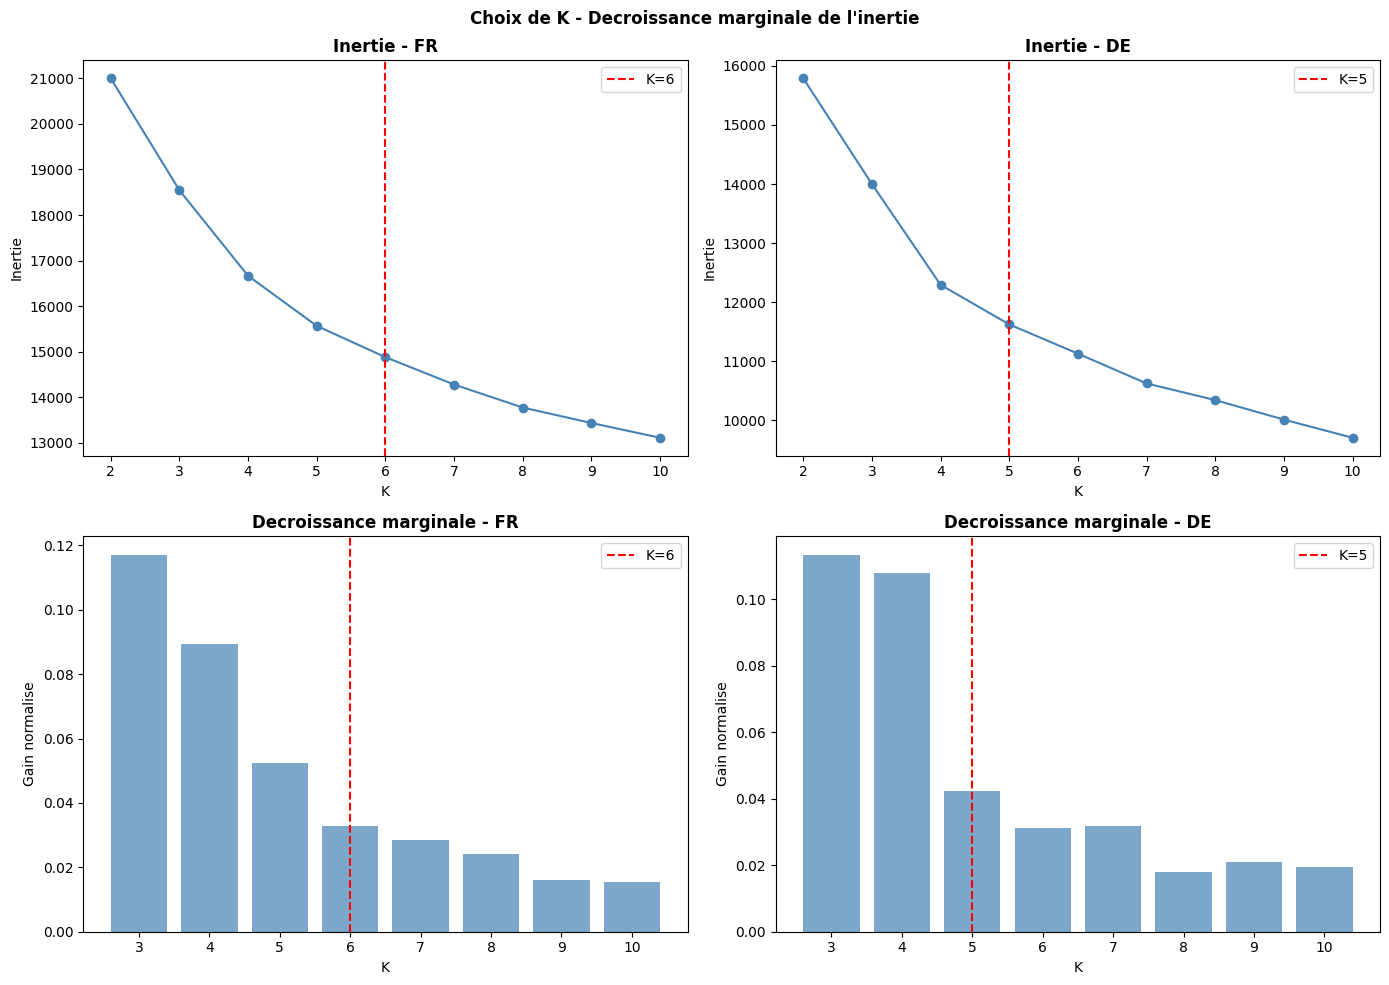

In [12]:
K_range = range(2, 11)

def marginal_decrease(inertias):
    '''
    Decroissance marginale de l'inertie entre chaque K.
    Normalisee par l'inertie initiale.
    '''
    inertias = np.array(inertias)
    margins  = (inertias[:-1] - inertias[1:]) / inertias[0]
    return margins, elbow_threshold(margins)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Choix de K - Decroissance marginale de l'inertie", fontweight='bold')

kmeans_models = {}
optimal_k     = {}

for col, country in enumerate(['FR', 'DE']):
    X = (x_train_fr if country == 'FR' else x_train_de).values
    inertias = [KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=SEED)
                .fit(X).inertia_ for k in K_range]

    margins, mi        = marginal_decrease(np.array(inertias))
    k_final            = list(K_range)[1:][mi]
    optimal_k[country] = k_final
    print(f"{country} | K retenu = {k_final}")

    axes[0, col].plot(K_range, inertias, marker='o', color='steelblue')
    axes[0, col].axvline(k_final, color='red', linestyle='--', label=f'K={k_final}')
    axes[0, col].set_title(f'Inertie - {country}', fontweight='bold')
    axes[0, col].set_xlabel('K'); axes[0, col].set_ylabel('Inertie'); axes[0, col].legend()

    axes[1, col].bar(list(K_range)[1:], margins, color='steelblue', alpha=0.7)
    axes[1, col].axvline(k_final, color='red', linestyle='--', label=f'K={k_final}')
    axes[1, col].set_title(f'Decroissance marginale - {country}', fontweight='bold')
    axes[1, col].set_xlabel('K'); axes[1, col].set_ylabel('Gain normalise'); axes[1, col].legend()

plt.tight_layout(); plt.show()

### 6.2 Entrainement KMeans et profil des clusters


============================================================  FR (K=6)
           N  Moyenne  Mediane    Std  Pct_pos  pct_total
CLUSTER                                                  
0        210    0.119    0.012  0.959   50.476       24.7
1        130   -0.172   -0.050  1.069   40.000       15.3
2        128    0.126    0.015  1.392   53.906       15.0
3        134   -0.040   -0.032  0.900   43.284       15.7
4        106    0.128   -0.002  1.096   49.057       12.5
5        143    0.084    0.008  0.654   53.147       16.8


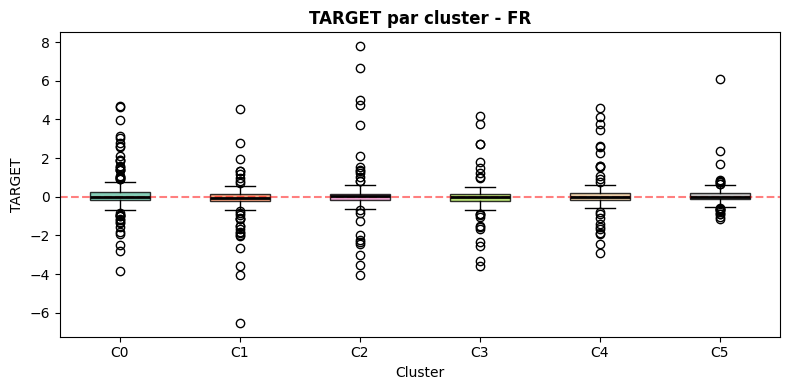

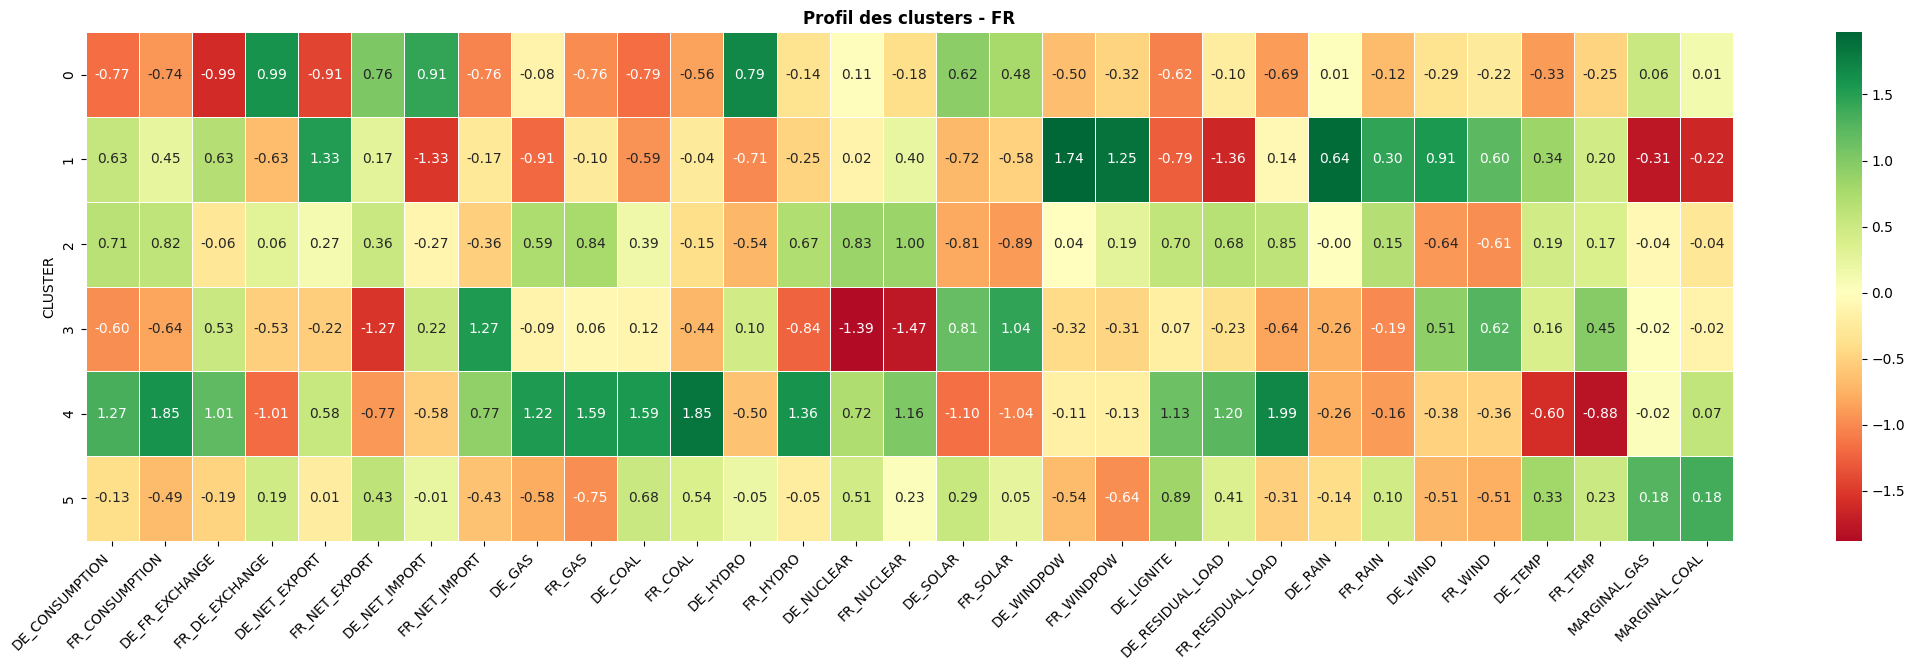


============================================================  DE (K=5)
           N  Moyenne  Mediane    Std  Pct_pos  pct_total
CLUSTER                                                  
0         94    0.403    0.135  0.968   57.447       14.6
1        225    0.289    0.083  1.177   57.333       35.0
2         81    0.233    0.145  1.058   53.086       12.6
3        135    0.169    0.006  0.615   54.074       21.0
4        108   -0.457   -0.619  1.037   24.074       16.8


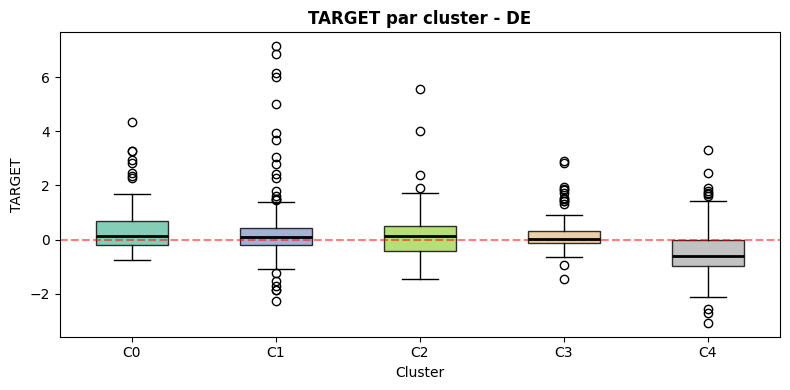

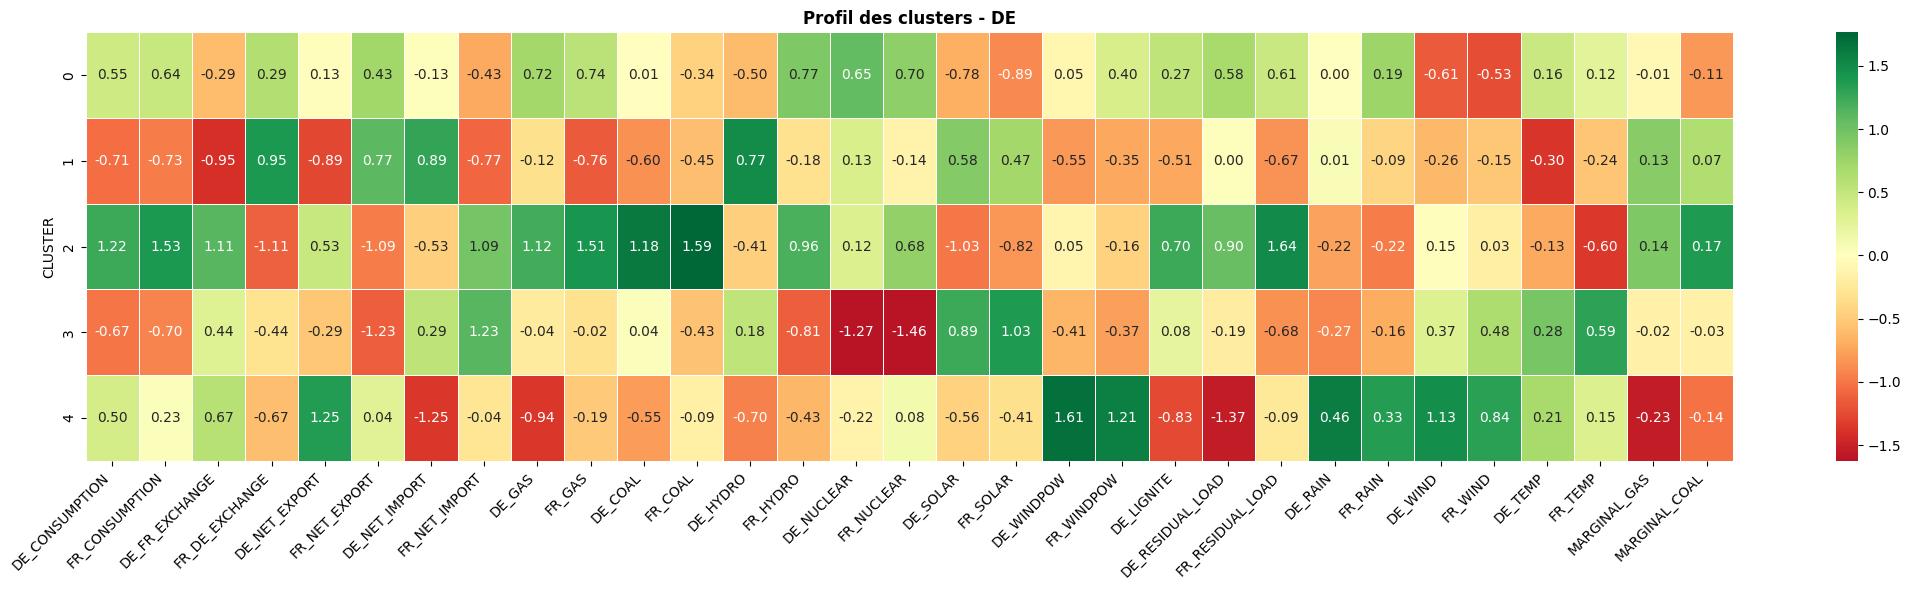

In [13]:
cluster_labels = {}

for country in ['FR', 'DE']:
    X_tr = (x_train_fr if country == 'FR' else x_train_de).values
    X_te = (x_test_fr  if country == 'FR' else x_test_de).values
    y_tr = y_fr_values if country == 'FR' else y_de_values
    X_df = x_train_fr  if country == 'FR' else x_train_de

    km = KMeans(n_clusters=optimal_k[country], init='k-means++', n_init=10, random_state=SEED)
    km.fit(X_tr)
    kmeans_models[country]  = km
    labels_train            = km.predict(X_tr)
    labels_test             = km.predict(X_te)
    cluster_labels[country] = {'train': labels_train, 'test': labels_test}

    df_cl            = X_df.copy()
    df_cl['CLUSTER'] = labels_train
    df_cl['TARGET']  = y_tr.values

    stats = df_cl.groupby('CLUSTER')['TARGET'].agg([
        ('N', 'count'), ('Moyenne', 'mean'), ('Mediane', 'median'),
        ('Std', 'std'), ('Pct_pos', lambda x: (x > 0).mean() * 100)
    ]).round(3)
    stats['pct_total'] = (stats['N'] / len(y_tr) * 100).round(1)
    print(f"\n{'='*60}  {country} (K={optimal_k[country]})")
    print(stats.to_string())

    # Boxplot
    fig, ax = plt.subplots(figsize=(8, 4))
    data_by_cl = [df_cl[df_cl['CLUSTER'] == k]['TARGET'].values
                  for k in range(optimal_k[country])]
    bp = ax.boxplot(data_by_cl, labels=[f'C{k}' for k in range(optimal_k[country])],
                    patch_artist=True, medianprops={'color': 'black', 'linewidth': 2})
    colors = plt.cm.Set2(np.linspace(0, 1, optimal_k[country]))
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color); patch.set_alpha(0.8)
    ax.axhline(0, color='red', linestyle='--', alpha=0.5)
    ax.set_title(f'TARGET par cluster - {country}', fontweight='bold')
    ax.set_xlabel('Cluster'); ax.set_ylabel('TARGET')
    plt.tight_layout(); plt.show()

    # Heatmap features par cluster
    feat_means      = df_cl.groupby('CLUSTER')[X_df.columns.tolist()].mean()
    feat_means_norm = (feat_means - feat_means.mean()) / feat_means.std().replace(0, 1)
    fig, ax = plt.subplots(figsize=(max(10, len(X_df.columns) * 0.7), optimal_k[country] * 0.8 + 2))
    sns.heatmap(feat_means_norm, annot=feat_means.round(2), fmt='.2f',
                cmap='RdYlGn', center=0, linewidths=0.5, ax=ax)
    ax.set_title(f'Profil des clusters - {country}', fontweight='bold')
    plt.xticks(rotation=45, ha='right'); plt.tight_layout(); plt.show()

### 6.3 Ridge + Cluster OHE Par pays

In [14]:
results['Ridge_Cluster'] = {}

print("="*80)
print(" RIDGE + CLUSTER OHE - PAR PAYS")
print("="*80)

for country, X_tr_base, X_te_base, y_vals, y_rnk in [
    ('FR', x_train_fr, x_test_fr, y_fr_values, y_fr_rank),
    ('DE', x_train_de, x_test_de, y_de_values, y_de_rank),
]:
    labels_train = cluster_labels[country]['train']
    labels_test  = cluster_labels[country]['test']

    ohe_tr = pd.get_dummies(labels_train, prefix='C').set_index(X_tr_base.index)
    ohe_te = pd.get_dummies(labels_test,  prefix='C').set_index(X_te_base.index)
    ohe_te = ohe_te.reindex(columns=ohe_tr.columns, fill_value=0)

    X_tr_ohe = pd.concat([X_tr_base, ohe_tr], axis=1)
    X_te_ohe = pd.concat([X_te_base, ohe_te], axis=1)

    for target_type, y in [('values', y_vals), ('rank', y_rnk)]:
        best_alpha = find_best_alpha_elbow(Ridge, alphas, X_tr_ohe, y)
        model      = Ridge(alpha=best_alpha)
        s_cv, s_tr, _ = fit_eval(model, X_tr_ohe, y,
                                  f"Ridge+Cluster {country} - {target_type} | alpha={best_alpha:.3f}")
        results['Ridge_Cluster'][f'{country}_{target_type}'] = {
            'score_cv': s_cv, 'score_train': s_tr,
            'model': model, 'params': {'alpha': best_alpha},
            'x_train': X_tr_ohe, 'x_test': X_te_ohe}

 RIDGE + CLUSTER OHE - PAR PAYS
  Ridge+Cluster FR - values | alpha=138.950          | CV=0.1715 | Train=0.2412 | Gap=0.0697 [WARN]
  Ridge+Cluster FR - rank | alpha=138.950            | CV=0.2165 | Train=0.2914 | Gap=0.0749 [WARN]
  Ridge+Cluster DE - values | alpha=79.060           | CV=0.3458 | Train=0.4433 | Gap=0.0975 [WARN]
  Ridge+Cluster DE - rank | alpha=44.984             | CV=0.3640 | Train=0.4552 | Gap=0.0912 [WARN]


### 6.4 Comparaison clustering vs baseline

In [15]:
print_comparison_table(results['Ridge_Cluster'], "RIDGE + CLUSTER OHE - COMPARAISON")

print("\nApport du clustering (Ridge vs Ridge+Cluster) :")
for key in ['FR_values', 'FR_rank', 'DE_values', 'DE_rank']:
    s_ridge   = results['Ridge'].get(key, {}).get('score_cv', None)
    s_cluster = results['Ridge_Cluster'].get(key, {}).get('score_cv', None)
    alpha     = results['Ridge_Cluster'].get(key, {}).get('params', {}).get('alpha', None)
    if s_ridge and s_cluster:
        gain = s_cluster - s_ridge
        print(f"  {key:15s} | alpha={alpha:.4f} | Ridge={s_ridge:.4f} | Ridge+Cluster={s_cluster:.4f} | Gain={gain:+.4f}")

# Soumissions Ridge + Cluster
for target_type in ['values', 'rank']:
    sub = pd.concat([
        pd.DataFrame({'ID': IDS_FR,
                      'TARGET': results['Ridge_Cluster'][f'FR_{target_type}']['model'].predict(
                                results['Ridge_Cluster'][f'FR_{target_type}']['x_test'])}),
        pd.DataFrame({'ID': IDS_DE,
                      'TARGET': results['Ridge_Cluster'][f'DE_{target_type}']['model'].predict(
                                results['Ridge_Cluster'][f'DE_{target_type}']['x_test'])}),
    ]).sort_values('ID').reset_index(drop=True)
    fname = f'submissions/submission_ridge_cluster_{target_type}.csv'
    sub.to_csv(fname, index=False)
    print(f"submission {fname} genere ({len(sub)} lignes)")


 RIDGE + CLUSTER OHE - COMPARAISON
  Modele                                             | CV      | Train   | Gap    | Diag
  ----------------------------------------------------------------------------
  FR_values                                          | 0.1715 | 0.2412 | 0.0697 | WARN
  FR_rank                                            | 0.2165 | 0.2914 | 0.0749 | WARN
  DE_values                                          | 0.3458 | 0.4433 | 0.0975 | WARN
  DE_rank                                            | 0.3640 | 0.4552 | 0.0912 | WARN

Apport du clustering (Ridge vs Ridge+Cluster) :
  FR_values       | alpha=138.9495 | Ridge=0.1694 | Ridge+Cluster=0.1715 | Gain=+0.0021
  FR_rank         | alpha=138.9495 | Ridge=0.2144 | Ridge+Cluster=0.2165 | Gain=+0.0020
  DE_values       | alpha=79.0604 | Ridge=0.3366 | Ridge+Cluster=0.3458 | Gain=+0.0091
  DE_rank         | alpha=44.9843 | Ridge=0.3566 | Ridge+Cluster=0.3640 | Gain=+0.0074
submission submissions/submission_ridge_cluster_v

## 7. Random Forest

Modele ensembliste par **bagging** : combine des arbres entraines sur des sous-echantillons avec sous-selection aleatoire des features. Robuste aux outliers, capture les non-linearites.

**Selection des features** : MDI cumulatif avec seuil optimal par CV sans leakage.
**Hyperparametres** : RandomizedSearchCV (n_estimators, max_features, max_depth, min_samples_leaf, max_samples).

### 7.1 Selection des features (MDI)

  FR | seuil=0.80 | 22 features retenues : ['MARGINAL_GAS', 'DE_SOLAR', 'FR_WINDPOW', 'FR_DE_EXCHANGE', 'FR_GAS', 'MARGINAL_COAL', 'DE_GAS', 'DE_RAIN', 'DE_FR_EXCHANGE', 'DE_CONSUMPTION', 'FR_SOLAR', 'FR_NUCLEAR', 'DE_RESIDUAL_LOAD', 'FR_CONSUMPTION', 'FR_TEMP', 'FR_RESIDUAL_LOAD', 'FR_WIND', 'FR_HYDRO', 'DE_LIGNITE', 'DE_WIND', 'DE_COAL', 'DE_NUCLEAR']
  DE | seuil=0.90 | 25 features retenues : ['DE_WINDPOW', 'DE_RESIDUAL_LOAD', 'DE_WIND', 'MARGINAL_GAS', 'FR_GAS', 'MARGINAL_COAL', 'DE_SOLAR', 'DE_RAIN', 'DE_LIGNITE', 'DE_NET_IMPORT', 'DE_TEMP', 'DE_GAS', 'DE_NET_EXPORT', 'DE_HYDRO', 'FR_WIND', 'FR_WINDPOW', 'DE_CONSUMPTION', 'FR_CONSUMPTION', 'DE_NUCLEAR', 'FR_SOLAR', 'FR_TEMP', 'FR_DE_EXCHANGE', 'FR_COAL', 'DE_FR_EXCHANGE', 'DE_COAL']


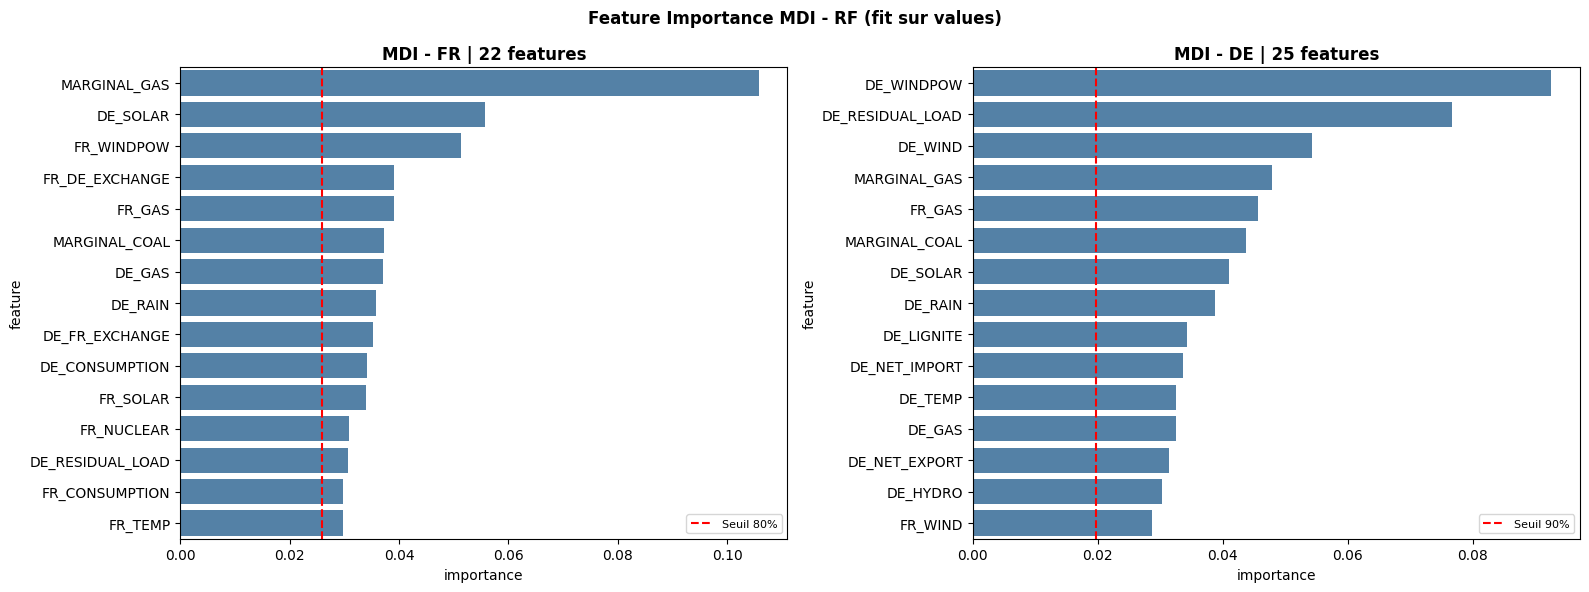

In [16]:
THRESHOLDS = np.arange(0.50, 1.00, 0.05)
N_ITER     = 30

def select_features_mdi(X, y, thresholds=THRESHOLDS, label=''):
    '''
    Selectionne les features par importance MDI cumulative.
    Seuil optimal par methode du coude sur Spearman CV (sans leakage).
    Retourne (seuil optimal, liste des features, importance series).
    '''
    kf      = KFold(n_splits=5, shuffle=True, random_state=SEED)
    res_cv  = []

    for thresh in thresholds:
        sp_folds = []
        for tr_idx, val_idx in kf.split(X):
            Xtr, Xval = X.iloc[tr_idx], X.iloc[val_idx]
            ytr, yval = y.iloc[tr_idx], y.iloc[val_idx]
            rf_s = RandomForestRegressor(n_estimators=100, random_state=SEED, n_jobs=-1)
            rf_s.fit(Xtr, ytr)
            imp  = pd.Series(rf_s.feature_importances_, index=X.columns).sort_values(ascending=False)
            cum  = imp.cumsum() / imp.sum()
            ns   = min((cum <= thresh).sum() + 1, len(imp))
            cols = imp[imp >= imp.values[ns-1]].index.tolist()
            rf_cv = RandomForestRegressor(n_estimators=100, random_state=SEED, n_jobs=-1)
            rf_cv.fit(Xtr[cols], ytr)
            sp_folds.append(spearmanr(yval, rf_cv.predict(Xval[cols])).correlation)
        res_cv.append({'threshold': thresh, 'spearman_mean': np.mean(sp_folds)})

    res_df = pd.DataFrame(res_cv)
    opt_t  = res_df['threshold'].iloc[elbow_threshold(res_df['spearman_mean'].values)]

    rf_full = RandomForestRegressor(n_estimators=200, random_state=SEED, n_jobs=-1)
    rf_full.fit(X, y)
    imp     = pd.Series(rf_full.feature_importances_, index=X.columns).sort_values(ascending=False)
    cum     = imp.cumsum() / imp.sum()
    ns      = min((cum <= opt_t).sum() + 1, len(imp))
    feats   = imp[imp >= imp.values[ns-1]].index.tolist()

    print(f"  {label} | seuil={opt_t:.2f} | {len(feats)} features retenues : {feats}")
    return opt_t, feats, imp

selected_features = {}
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Feature Importance MDI - RF (fit sur values)", fontweight='bold')

for ax, country, X_tr, y_tr in [
    (axes[0], 'FR', x_train_fr, y_fr_values),
    (axes[1], 'DE', x_train_de, y_de_values),
]:
    opt_t, feats, imp = select_features_mdi(X_tr, y_tr, label=country)
    selected_features[country] = feats
    thr = imp.values[min((imp.cumsum()/imp.sum() <= opt_t).sum(), len(imp)-1)]

    imp_df = imp.reset_index()
    imp_df.columns = ['feature', 'importance']
    sns.barplot(data=imp_df.head(15), y='feature', x='importance', ax=ax, color='steelblue')
    ax.axvline(thr, color='red', linestyle='--', label=f'Seuil {opt_t*100:.0f}%')
    ax.set_title(f'MDI - {country} | {len(feats)} features', fontweight='bold')
    ax.legend(fontsize=8)

plt.tight_layout(); plt.show()

### 7.2 RF Full dataset

In [17]:
results['RF'] = {}

print("="*80)
print(" RF - FULL DATASET")
print("="*80)

for target_type, y in [('values', y_full_values), ('rank', y_full_rank)]:
    rs = RandomizedSearchCV(
        RandomForestRegressor(random_state=SEED, n_jobs=-1),
        {'n_estimators': [100, 200, 500], 'max_features': ['sqrt', 'log2', 0.5],
         'max_depth': [None, 10, 20, 30], 'min_samples_leaf': [1, 3, 5, 10],
         'max_samples': [0.6, 0.8, 1.0]},
        n_iter=N_ITER, cv=cv, scoring=spearman_metric, random_state=SEED, n_jobs=-1)
    rs.fit(X_full, y)
    model = rs.best_estimator_
    model.fit(X_full, y)
    s_tr = spearmanr(y, model.predict(X_full)).correlation
    s_cv = rs.best_score_
    gap  = s_tr - s_cv
    diag = 'OK' if gap < 0.05 else ('WARN' if gap < 0.15 else 'OVERFIT')
    print(f"  {'RF full - ' + target_type:50s} | CV={s_cv:.4f} | Train={s_tr:.4f} | Gap={gap:.4f} [{diag}]")
    print(f"    Params : {rs.best_params_}")
    results['RF'][f'full_{target_type}'] = {'score_cv': s_cv, 'score_train': s_tr,
                                             'model': model, 'params': rs.best_params_,
                                             'x_test': X_test_full}

 RF - FULL DATASET
  RF full - values                                   | CV=0.0309 | Train=0.4732 | Gap=0.4422 [OVERFIT]
    Params : {'n_estimators': 100, 'min_samples_leaf': 10, 'max_samples': 0.6, 'max_features': 'log2', 'max_depth': 10}
  RF full - rank                                     | CV=0.0272 | Train=0.6802 | Gap=0.6529 [OVERFIT]
    Params : {'n_estimators': 200, 'min_samples_leaf': 10, 'max_samples': 0.8, 'max_features': 'log2', 'max_depth': 30}


### 7.3 RF Par pays

In [18]:
print("="*80)
print(" RF - PAR PAYS")
print("="*80)

for country, X_tr_base, y_vals, y_rnk in [
    ('FR', x_train_fr, y_fr_values, y_fr_rank),
    ('DE', x_train_de, y_de_values, y_de_rank),
]:
    feats = selected_features[country]
    X_tr  = X_tr_base[feats]
    X_te  = (x_test_fr if country == 'FR' else x_test_de)[feats]

    for target_type, y in [('values', y_vals), ('rank', y_rnk)]:
        rs = RandomizedSearchCV(
            RandomForestRegressor(random_state=SEED, n_jobs=-1),
            {'n_estimators': [100, 200, 500], 'max_features': ['sqrt', 'log2', 0.5],
             'max_depth': [None, 10, 20, 30], 'min_samples_leaf': [1, 3, 5, 10],
             'max_samples': [0.6, 0.8, 1.0]},
            n_iter=N_ITER, cv=cv, scoring=spearman_metric, random_state=SEED, n_jobs=-1)
        rs.fit(X_tr, y)
        model = rs.best_estimator_
        model.fit(X_tr, y)
        s_tr = spearmanr(y, model.predict(X_tr)).correlation
        s_cv = rs.best_score_
        gap  = s_tr - s_cv
        diag = 'OK' if gap < 0.05 else ('WARN' if gap < 0.15 else 'OVERFIT')
        print(f"  {'RF ' + country + ' - ' + target_type:50s} | CV={s_cv:.4f} | Train={s_tr:.4f} | Gap={gap:.4f} [{diag}]")
        print(f"    Params : {rs.best_params_}")
        results['RF'][f'{country}_{target_type}'] = {
            'score_cv': s_cv, 'score_train': s_tr,
            'model': model, 'params': rs.best_params_,
            'features': feats, 'x_test': X_te}

 RF - PAR PAYS
  RF FR - values                                     | CV=0.1428 | Train=0.7467 | Gap=0.6038 [OVERFIT]
    Params : {'n_estimators': 100, 'min_samples_leaf': 3, 'max_samples': 0.6, 'max_features': 0.5, 'max_depth': None}
  RF FR - rank                                       | CV=0.1573 | Train=0.9336 | Gap=0.7763 [OVERFIT]
    Params : {'n_estimators': 200, 'min_samples_leaf': 1, 'max_samples': 0.8, 'max_features': 'log2', 'max_depth': 10}
  RF DE - values                                     | CV=0.3328 | Train=0.6591 | Gap=0.3263 [OVERFIT]
    Params : {'n_estimators': 100, 'min_samples_leaf': 10, 'max_samples': 0.6, 'max_features': 'log2', 'max_depth': 10}
  RF DE - rank                                       | CV=0.3601 | Train=0.6911 | Gap=0.3310 [OVERFIT]
    Params : {'n_estimators': 100, 'min_samples_leaf': 10, 'max_samples': 0.6, 'max_features': 'sqrt', 'max_depth': None}


### 7.4 Analyse RF


 RF - COMPARAISON COMPLETE
  Modele                                             | CV      | Train   | Gap    | Diag
  ----------------------------------------------------------------------------
  full_values                                        | 0.0309 | 0.4732 | 0.4422 | OVERFIT
  full_rank                                          | 0.0272 | 0.6802 | 0.6529 | OVERFIT
  FR_values                                          | 0.1428 | 0.7467 | 0.6038 | OVERFIT
  FR_rank                                            | 0.1573 | 0.9336 | 0.7763 | OVERFIT
  DE_values                                          | 0.3328 | 0.6591 | 0.3263 | OVERFIT
  DE_rank                                            | 0.3601 | 0.6911 | 0.3310 | OVERFIT

RF vs Ridge - par pays :
  FR_values       | Ridge=0.1694 | RF=0.1428 | Gain=-0.0265
  FR_rank         | Ridge=0.2144 | RF=0.1573 | Gain=-0.0571
  DE_values       | Ridge=0.3366 | RF=0.3328 | Gain=-0.0038
  DE_rank         | Ridge=0.3566 | RF=0.3601 | Gain=+0.003

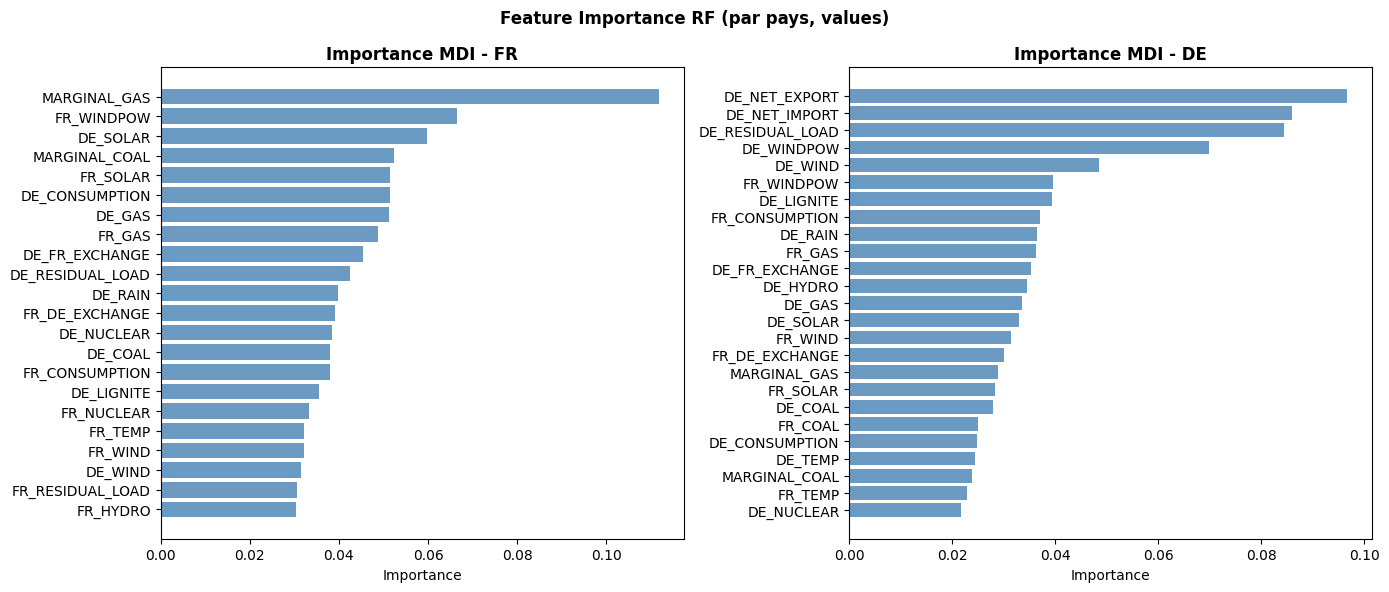

In [19]:
print_comparison_table(results['RF'], "RF - COMPARAISON COMPLETE")

print("\nRF vs Ridge - par pays :")
for key in ['FR_values', 'FR_rank', 'DE_values', 'DE_rank']:
    s_ridge = results['Ridge'].get(key, {}).get('score_cv', None)
    s_rf    = results['RF'].get(key, {}).get('score_cv', None)
    if s_ridge and s_rf:
        print(f"  {key:15s} | Ridge={s_ridge:.4f} | RF={s_rf:.4f} | Gain={s_rf-s_ridge:+.4f}")

# Feature importance RF par pays
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Feature Importance RF (par pays, values)", fontweight='bold')
for ax, country, X_tr in [(axes[0], 'FR', x_train_fr), (axes[1], 'DE', x_train_de)]:
    feats = selected_features[country]
    m     = results['RF'][f'{country}_values']['model']
    imp   = pd.Series(m.feature_importances_, index=feats).sort_values(ascending=True)
    ax.barh(imp.index, imp.values, color='steelblue', alpha=0.8)
    ax.set_title(f'Importance MDI - {country}', fontweight='bold')
    ax.set_xlabel('Importance')
plt.tight_layout(); plt.show()

## 8. Gradient Boosting

Modele ensembliste par **boosting sequentiel** : chaque arbre corrige les residus du precedent
(descente de gradient dans l'espace fonctionnel). Capture des non-linearites plus fines que le RF
mais plus sensible au surapprentissage (surveiller le gap Train/CV).

### 8.1 GB Full dataset

In [20]:
results['GB'] = {}

print("="*80)
print(" GB - FULL DATASET")
print("="*80)

for target_type, y in [('values', y_full_values), ('rank', y_full_rank)]:
    rs = RandomizedSearchCV(
        GradientBoostingRegressor(random_state=SEED),
        {'n_estimators': [100, 200, 500], 'learning_rate': [0.01, 0.05, 0.1, 0.2],
         'max_depth': [3, 5, 7], 'subsample': [0.6, 0.8, 1.0],
         'min_samples_leaf': [1, 3, 5]},
        n_iter=N_ITER, cv=cv, scoring=spearman_metric, random_state=SEED, n_jobs=-1)
    rs.fit(X_full, y)
    model = rs.best_estimator_
    model.fit(X_full, y)
    s_tr = spearmanr(y, model.predict(X_full)).correlation
    s_cv = rs.best_score_
    gap  = s_tr - s_cv
    diag = 'OK' if gap < 0.05 else ('WARN' if gap < 0.15 else 'OVERFIT')
    print(f"  {'GB full - ' + target_type:50s} | CV={s_cv:.4f} | Train={s_tr:.4f} | Gap={gap:.4f} [{diag}]")
    print(f"    Params : {rs.best_params_}")
    results['GB'][f'full_{target_type}'] = {'score_cv': s_cv, 'score_train': s_tr,
                                             'model': model, 'params': rs.best_params_,
                                             'x_test': X_test_full}

 GB - FULL DATASET
  GB full - values                                   | CV=0.0318 | Train=0.7144 | Gap=0.6826 [OVERFIT]
    Params : {'subsample': 1.0, 'n_estimators': 200, 'min_samples_leaf': 1, 'max_depth': 7, 'learning_rate': 0.2}
  GB full - rank                                     | CV=0.0284 | Train=0.6503 | Gap=0.6219 [OVERFIT]
    Params : {'subsample': 0.6, 'n_estimators': 200, 'min_samples_leaf': 3, 'max_depth': 3, 'learning_rate': 0.05}


### 8.2 GB Par pays

In [21]:
print("="*80)
print(" GB - PAR PAYS")
print("="*80)

for country, X_tr_base, y_vals, y_rnk in [
    ('FR', x_train_fr, y_fr_values, y_fr_rank),
    ('DE', x_train_de, y_de_values, y_de_rank),
]:
    feats = selected_features[country]
    X_tr  = X_tr_base[feats]
    X_te  = (x_test_fr if country == 'FR' else x_test_de)[feats]

    for target_type, y in [('values', y_vals), ('rank', y_rnk)]:
        rs = RandomizedSearchCV(
            GradientBoostingRegressor(random_state=SEED),
            {'n_estimators': [100, 200, 500], 'learning_rate': [0.01, 0.05, 0.1, 0.2],
             'max_depth': [3, 5, 7], 'subsample': [0.6, 0.8, 1.0],
             'min_samples_leaf': [1, 3, 5]},
            n_iter=N_ITER, cv=cv, scoring=spearman_metric, random_state=SEED, n_jobs=-1)
        rs.fit(X_tr, y)
        model = rs.best_estimator_
        model.fit(X_tr, y)
        s_tr = spearmanr(y, model.predict(X_tr)).correlation
        s_cv = rs.best_score_
        gap  = s_tr - s_cv
        diag = 'OK' if gap < 0.05 else ('WARN' if gap < 0.15 else 'OVERFIT')
        print(f"  {'GB ' + country + ' - ' + target_type:50s} | CV={s_cv:.4f} | Train={s_tr:.4f} | Gap={gap:.4f} [{diag}]")
        print(f"    Params : {rs.best_params_}")
        results['GB'][f'{country}_{target_type}'] = {
            'score_cv': s_cv, 'score_train': s_tr,
            'model': model, 'params': rs.best_params_,
            'features': feats, 'x_test': X_te}

 GB - PAR PAYS
  GB FR - values                                     | CV=0.1214 | Train=0.5690 | Gap=0.4476 [OVERFIT]
    Params : {'subsample': 0.6, 'n_estimators': 100, 'min_samples_leaf': 1, 'max_depth': 5, 'learning_rate': 0.05}
  GB FR - rank                                       | CV=0.1622 | Train=0.5139 | Gap=0.3517 [OVERFIT]
    Params : {'subsample': 0.6, 'n_estimators': 100, 'min_samples_leaf': 3, 'max_depth': 3, 'learning_rate': 0.01}
  GB DE - values                                     | CV=0.2647 | Train=0.6591 | Gap=0.3944 [OVERFIT]
    Params : {'subsample': 0.8, 'n_estimators': 100, 'min_samples_leaf': 5, 'max_depth': 5, 'learning_rate': 0.01}
  GB DE - rank                                       | CV=0.3359 | Train=0.8341 | Gap=0.4982 [OVERFIT]
    Params : {'subsample': 0.8, 'n_estimators': 100, 'min_samples_leaf': 5, 'max_depth': 5, 'learning_rate': 0.01}


### 8.3 Analyse GB

In [22]:
print_comparison_table(results['GB'], "GB - COMPARAISON COMPLETE")

print("\nGB vs RF - par pays :")
for key in ['FR_values', 'FR_rank', 'DE_values', 'DE_rank']:
    s_rf = results['RF'].get(key, {}).get('score_cv', None)
    s_gb = results['GB'].get(key, {}).get('score_cv', None)
    if s_rf and s_gb:
        print(f"  {key:15s} | RF={s_rf:.4f} | GB={s_gb:.4f} | Gain={s_gb-s_rf:+.4f}")


 GB - COMPARAISON COMPLETE
  Modele                                             | CV      | Train   | Gap    | Diag
  ----------------------------------------------------------------------------
  full_values                                        | 0.0318 | 0.7144 | 0.6826 | OVERFIT
  full_rank                                          | 0.0284 | 0.6503 | 0.6219 | OVERFIT
  FR_values                                          | 0.1214 | 0.5690 | 0.4476 | OVERFIT
  FR_rank                                            | 0.1622 | 0.5139 | 0.3517 | OVERFIT
  DE_values                                          | 0.2647 | 0.6591 | 0.3944 | OVERFIT
  DE_rank                                            | 0.3359 | 0.8341 | 0.4982 | OVERFIT

GB vs RF - par pays :
  FR_values       | RF=0.1428 | GB=0.1214 | Gain=-0.0215
  FR_rank         | RF=0.1573 | GB=0.1622 | Gain=+0.0049
  DE_values       | RF=0.3328 | GB=0.2647 | Gain=-0.0681
  DE_rank         | RF=0.3601 | GB=0.3359 | Gain=-0.0242


## 9. Interpretabilite (SHAP)

SHAP (Shapley Additive Explanations) interprete les predictions du meilleur RF.
- **Summary plot** : importance globale et direction d'influence de chaque feature
- **Force plot**   : explication d'une prediction individuelle (observation extreme)

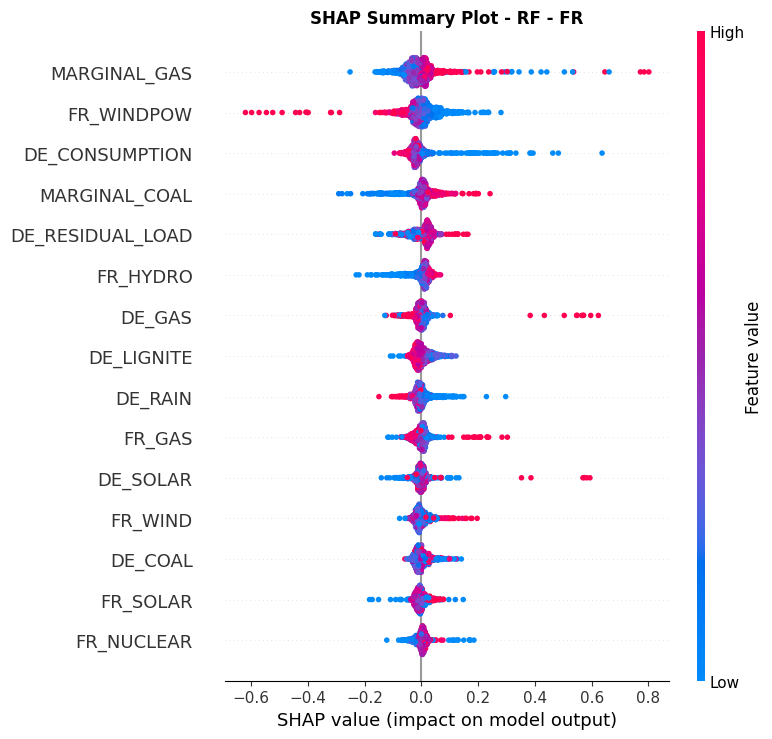

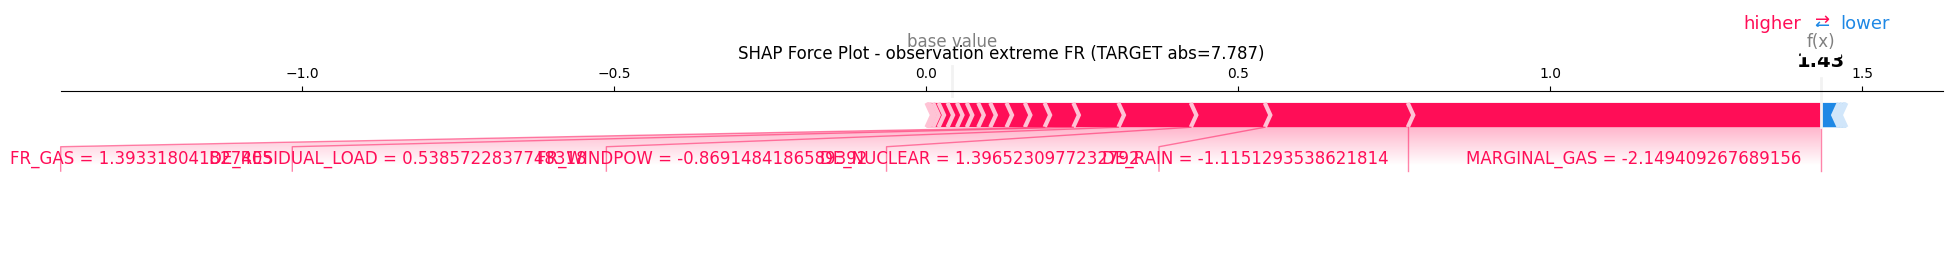

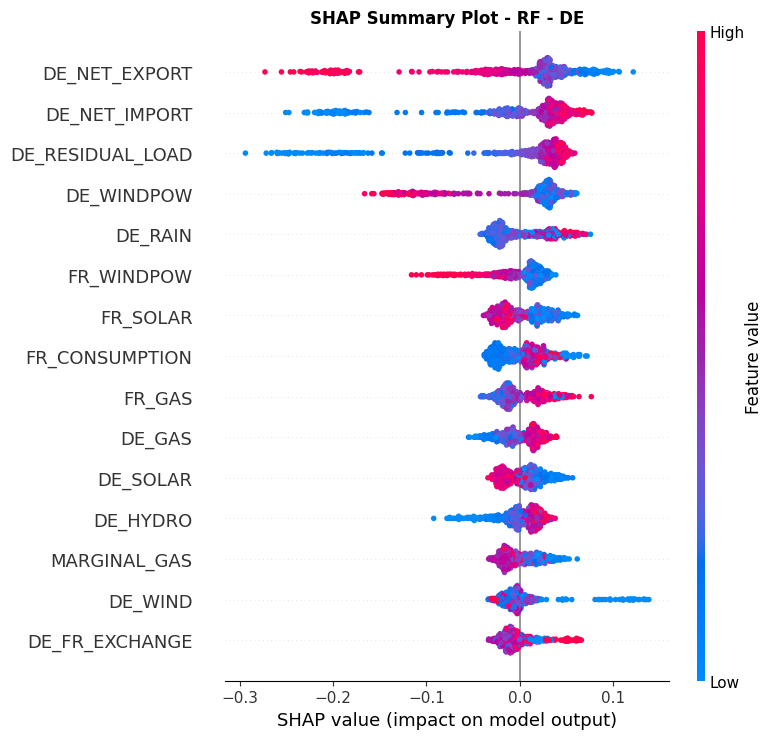

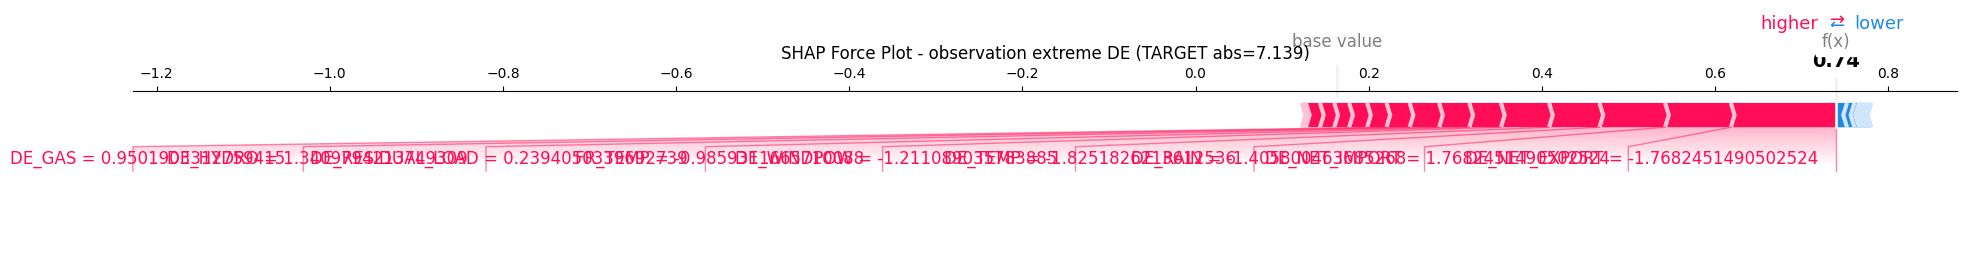

In [23]:
for country in ['FR', 'DE']:
    d     = results['RF'][f'{country}_values']
    rf    = d['model']
    feats = d['features']
    X     = (x_train_fr if country == 'FR' else x_train_de)[feats]
    y_ref = y_fr_values if country == 'FR' else y_de_values

    explainer   = shap.TreeExplainer(rf)
    shap_values = explainer.shap_values(X)

    # Summary plot
    plt.figure(figsize=(10, 6))
    shap.summary_plot(shap_values, X, max_display=15, show=False)
    plt.title(f'SHAP Summary Plot - RF - {country}', fontweight='bold')
    plt.tight_layout(); plt.show()

    # Force plot - observation la plus extreme
    idx_ext = X.index.get_loc(y_ref.abs().idxmax())
    y_ext   = y_ref.abs().max()
    shap.force_plot(explainer.expected_value, shap_values[idx_ext, :],
                    X.iloc[idx_ext, :], matplotlib=True, show=False)
    plt.title(f'SHAP Force Plot - observation extreme {country} (TARGET abs={y_ext:.3f})')
    plt.tight_layout(); plt.show()

## 10. Comparaison finale et soumissions

In [24]:
# Tableau synthetique global
all_results = {}
for model_name in ['OLS', 'Ridge', 'Ridge_Cluster', 'RF', 'GB']:
    for key, d in results[model_name].items():
        all_results[f"{model_name} - {key}"] = d

print_comparison_table(all_results, "COMPARAISON FINALE - TOUS LES MODELES")

# Meilleure combinaison par pays
print(f"\n{'='*70}")
print(" MEILLEURE COMBINAISON PAR PAYS")
print(f"{'='*70}")
for country in ['FR', 'DE']:
    best_score = -np.inf
    best_label = ''
    for model_name in ['OLS', 'Ridge', 'Ridge_Cluster', 'RF', 'GB']:
        for target_type in ['values', 'rank']:
            key = f'{country}_{target_type}'
            if key in results[model_name]:
                s = results[model_name][key]['score_cv']
                if s > best_score:
                    best_score = s
                    best_label = f"{model_name} - {target_type}"
    print(f"  {country} -> {best_label} | Spearman CV = {best_score:.4f}")


 COMPARAISON FINALE - TOUS LES MODELES
  Modele                                             | CV      | Train   | Gap    | Diag
  ----------------------------------------------------------------------------
  OLS - full_values                                  | 0.0033 | 0.0831 | 0.0799 | WARN
  OLS - full_rank                                    | -0.0124 | 0.1194 | 0.1319 | WARN
  OLS - FR_values                                    | 0.1405 | 0.2215 | 0.0810 | WARN
  OLS - FR_rank                                      | 0.1910 | 0.2833 | 0.0923 | WARN
  OLS - DE_values                                    | 0.3227 | 0.4401 | 0.1174 | WARN
  OLS - DE_rank                                      | 0.3478 | 0.4513 | 0.1035 | WARN
  Ridge - full_values                                | 0.0089 | 0.0823 | 0.0734 | WARN
  Ridge - full_rank                                  | -0.0076 | 0.1170 | 0.1246 | WARN
  Ridge - FR_values                                  | 0.1694 | 0.2320 | 0.0626 | WARN
  Ridge

In [25]:
# Soumissions RF et GB par pays
print("\n" + "="*60)
print(" GENERATION DES SOUMISSIONS")
print("="*60)

for model_name in ['RF', 'GB']:
    for target_type in ['values', 'rank']:
        key_fr = f'FR_{target_type}'
        key_de = f'DE_{target_type}'
        if key_fr not in results[model_name] or key_de not in results[model_name]:
            continue

        d_fr = results[model_name][key_fr]
        d_de = results[model_name][key_de]
        pred_fr = d_fr['model'].predict(d_fr['x_test'])
        pred_de = d_de['model'].predict(d_de['x_test'])

        assert len(pred_fr) == len(IDS_FR), f"Mismatch FR [{model_name}/{target_type}]"
        assert len(pred_de) == len(IDS_DE), f"Mismatch DE [{model_name}/{target_type}]"

        sub = pd.concat([
            pd.DataFrame({'ID': IDS_FR, 'TARGET': pred_fr}),
            pd.DataFrame({'ID': IDS_DE, 'TARGET': pred_de}),
        ]).sort_values('ID').reset_index(drop=True)

        fname = f'submissions/submission_{model_name.lower()}_{target_type}.csv'
        sub.to_csv(fname, index=False)
        print(f"  {fname} ({len(sub)} lignes)")


 GENERATION DES SOUMISSIONS
  submissions/submission_rf_values.csv (654 lignes)
  submissions/submission_rf_rank.csv (654 lignes)
  submissions/submission_gb_values.csv (654 lignes)
  submissions/submission_gb_rank.csv (654 lignes)


## Conclusion

Les principaux enseignements :

1. **OLS vs Ridge** : la penalisation L2 ameliore la generalisation en reduisant la variance des coefficients.
2. **Full vs par pays** : la modelisation separee FR/DE est justifiee par les differences structurelles de mix energetique.
3. **Values vs Rank** : fitter sur les rangs aligne l'objectif d'entrainement avec la metrique Spearman.
4. **Clustering** : les clusters capturent des regimes de marche ; leur apport comme feature OHE depend de leur discrimination de la TARGET.
5. **RF/GB** : les methodes ensemblistes capturent les non-linearites et surpassent les modeles lineaires.
6. **SHAP** : les prix des matieres premieres (gaz, carbone) et la charge residuelle sont les principaux drivers.